<div style="text-align:center;">
<h2 style="color:#2e86c1; font-family:Arial, sans-serif; font-size:24px; font-weight:bold;">
STEP 2.DATA PRE-PROCESSING
</h2>
</div>

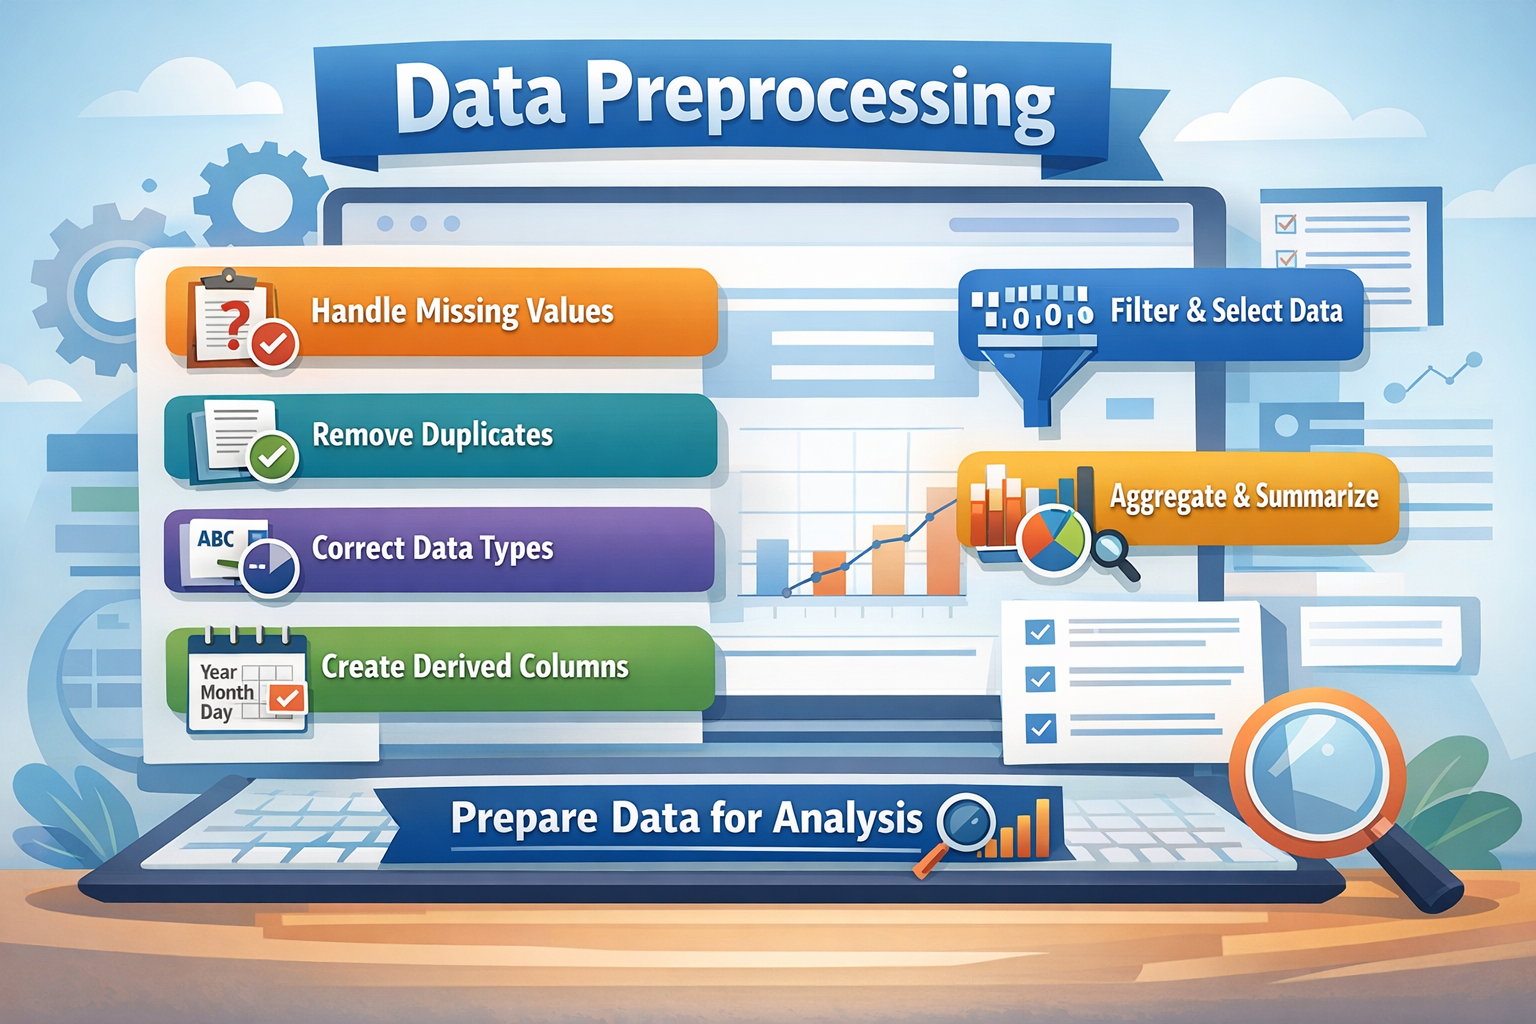

Data pre-processing is an important step in data analysis used to clean and prepare the dataset. Missing values and duplicate records were identified and handled using methods such as mean and mode. The Visit_Date column was converted into datetime format, and new columns like Year, Month, and Revenue_per_Visitor were created. After these steps, the dataset became ready for exploratory data analysis and further modeling

<div style="background-color:#e5e7eb; padding:8px; border-left:5px solid #2563eb; border-radius:5px;">
<h3 style="color:#1e3a8a; font-size:16px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
2.1 HANDLING MISSING VALUES
</h3>
</div>To identifying and addressing gaps (null or NaN) in a dataset by either removing, filling, or imputing them so the data is complete and suitable for analysis.

In [3]:
# Check missing values
import pandas as pd
import numpy as np

df = pd.read_csv("tourism dataset.csv")

df.isnull().sum()

Visit_ID               0
Tourist_Origin         0
Destination _City      1
Destination_Type       9
Visitor_Type           1
Season                 5
Visit_Date           123
Visitors_Count       249
Average_Rating         0
Revenue_USD            3
Average_Spending       0
dtype: int64

## Findings:

* Most columns have only a few missing values
* Destination_City and Visitor_Type have 1 missing value each
* Season has 5 missing values
* Destination_Type has 9 missing values
* Revenue_USD has 3 missing values
* Visit_Date has 123 missing values
* Visitors_Count has 249 missing values
* Visit_ID, Tourist_Origin, and Average_Rating have no missing values

In [4]:
# Handling Categorical Columns(fill with mode)
categorical_cols = ['Destination _City', 'Destination_Type', 'Visitor_Type', 'Season']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
# Numerical Columns (fill with median)
numerical_cols = ['Visitors_Count', 'Revenue_USD']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [6]:
# Date column (fill with forward fill)
# Forward fill: fill missing value with previous row's date

df['Visit_Date'] = df['Visit_Date'].ffill()


In [7]:
# Missing values after cleaning
print("\nMissing values AFTER cleaning:\n")
print(df.isnull().sum())


Missing values AFTER cleaning:

Visit_ID             0
Tourist_Origin       0
Destination _City    0
Destination_Type     0
Visitor_Type         0
Season               0
Visit_Date           0
Visitors_Count       0
Average_Rating       0
Revenue_USD          0
Average_Spending     0
dtype: int64


## Findings:

* All missing values have been successfully handled
* All columns now have 0 missing values
* The dataset is complete and clean
* Data consistency has been ensured
* The dataset is ready for further analysis
* It is suitable for visualization and modeling

<div style="background-color:#e5e7eb; padding:8px; border-left:5px solid #2563eb; border-radius:5px;">
<h3 style="color:#1e3a8a; font-size:16px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
2.2 REMOVING DUPLICATES
</h3>
</div>Changing a column’s data type (e.g., object → datetime, float → integer) to ensure accurate calculations, comparisons, and analysis.

In [8]:
# Check for Duplicate Rows
import pandas as pd

df = pd.read_csv("tourism dataset.csv")
df.duplicated().sum()

np.int64(0)

## Findings: 

* The dataset was checked for duplicates using df.duplicated()
* No duplicate rows were found in the dataset
* Each record is unique
* No duplicate removal was required
* The dataset is ready for further analysis

<div style="background-color:#e5e7eb; padding:8px; border-left:5px solid #2563eb; border-radius:5px;">
<h3 style="color:#1e3a8a; font-size:16px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
2.3  CORRECTING DATA TYPES
</h3>
</div>Changing a column’s data type (e.g., object → datetime, float → integer) to ensure accurate calculations, comparisons, and analysis.

In [9]:
# Check Current Data Types
df.dtypes

Visit_ID              object
Tourist_Origin        object
Destination _City     object
Destination_Type      object
Visitor_Type          object
Season                object
Visit_Date            object
Visitors_Count       float64
Average_Rating       float64
Revenue_USD          float64
Average_Spending     float64
dtype: object

In [11]:
# Convert Visit_Date to Date Format
df['Visit_Date'] = pd.to_datetime(df['Visit_Date'], errors='coerce')

In [12]:
# Convert Visitors_Count to Numeric
df['Visitors_Count'] = pd.to_numeric(df['Visitors_Count'], errors='coerce').astype('Int64')

In [13]:
# Check Data Types Again
df.dtypes

Visit_ID                     object
Tourist_Origin               object
Destination _City            object
Destination_Type             object
Visitor_Type                 object
Season                       object
Visit_Date           datetime64[ns]
Visitors_Count                Int64
Average_Rating              float64
Revenue_USD                 float64
Average_Spending            float64
dtype: object

## Findings:

* The dataset’s data types were checked and corrected
* Visit_Date was converted from object to datetime format
* Visitors_Count was converted to numeric
* These changes ensure data accuracy and consistency
* The dataset is now reliable for further analysis

<div style="background-color:#e5e7eb; padding:8px; border-left:5px solid #2563eb; border-radius:5px;">
<h3 style="color:#1e3a8a; font-size:16px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
2.4 CREATING DERIVED COLUMNS
</h3>
</div>Derived columns are new variables created from existing columns to simplify data analysis and reveal hidden patterns.

In [5]:
#Extracted Year, Month, Day from Visit_Date
import pandas as pd
df = pd.read_csv("tourism dataset.csv")
df['Visit_Date'] = pd.to_datetime(df['Visit_Date'], format='%m/%d/%Y', errors='coerce')
df = df.dropna(subset=['Visit_Date'])

df['Year'] = df['Visit_Date'].dt.year
df['Month'] = df['Visit_Date'].dt.month
df['Day'] = df['Visit_Date'].dt.day

df[['Year','Month','Day']] = df[['Year','Month','Day']].astype(int)

print(df[['Visit_Date','Year','Month','Day']].head())

  Visit_Date  Year  Month  Day
0 2021-08-17  2021      8   17
1 2021-03-07  2021      3    7
2 2022-03-28  2022      3   28
3 2021-07-29  2021      7   29
4 2023-02-15  2023      2   15


## Findings:

* New columns Year, Month, and Day were created from Visit_Date
* This enables analysis of tourism trends over time
* It allows more detailed time-based analysis
* The dataset becomes more useful for visualization
* Overall it enhances the depth of analysis

<div style="background-color:#e5e7eb; padding:8px; border-left:5px solid #2563eb; border-radius:5px;">
<h3 style="color:#1e3a8a; font-size:16px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
2.5 FILTERING OR AGGREGATING DATA
</h3>
</div>Filtering is the process of selecting specific data based on conditions, while aggregating involves summarizing data using operations like sum, mean, or count to extract meaningful insights.  

In [16]:
# Filtering Data
filtered_data = df[df['Visitors_Count'] > 1000]
filtered_data.head()

,Visit_ID,Tourist_Origin,Destination _City,Destination_Type,Visitor_Type,Season,Visit_Date,Visitors_Count,Average_Rating,Revenue_USD,Average_Spending,Year,Month,Day
2,VIS3,Dubai,India,City Tourism,International,Summer,2022-03-28,3689,4.41,682444.31,184.994391,2022.0,3.0,28.0
6,VIS7,Singapore,Kerala,Adventure,International,Summer,2021-05-27,5000,3.89,988969.60,197.793920,2021.0,5.0,27.0
8,VIS9,Singapore,Bali,Hill Station,International,Winter,2022-10-07,1751,3.16,356368.47,203.522827,2022.0,10.0,7.0
9,VIS10,Singapore,Rome,Hill Station,Domestic,Monsoon,2024-04-12,3519,4.65,955022.84,271.390406,2024.0,4.0,12.0
10,VIS11,Singapore,Singapore,Beach,International,Summer,2021-11-10,1320,3.13,319152.53,241.782220,2021.0,11.0,10.0


In [17]:
# Aggregating Data
df.groupby('Destination_Type')['Visitors_Count'].sum()

Destination_Type
Adventure       5129807
Beach           4920618
City Tourism    5062118
Heritage        4710902
Hill Station    4799605
Wildlife        4744591
Name: Visitors_Count, dtype: Int64

## Findings: 

* Filtering was applied to select specific records based on conditions
* Aggregation using groupby() was performed to summarize the data
* This helps in understanding tourism trends
* It also provides insights into visitor distribution

<div style="background-color:#eff6ff; padding:12px; border-left:6px solid #3b82f6; border-radius:6px;">
<h2 style="color:#1e3a8a; font-size:20px; margin:0; font-weight:bold;">
DATA PRE-PROCESSING SUMMARY
</h2>
</div>



* Missing values were handled and duplicate records were checked
* Data types were corrected to ensure proper analysis
* Derived columns were created for time-based analysis
* Data was filtered and aggregated to gain better insights
* These steps helped in understanding tourism trends
* Overall, the dataset’s quality, consistency, and usability were improved
* The dataset is now ready for further analysis and visualization